# From play histories to readable model inputs

**Checkpoint 3: verbalization, leakage checks, and token costs**

We now have popularity and ALS numbers to beat. This notebook prepares the text the
future Gemma ranker will read. It explains each exclusion, shows the cost of taking
only the most-played 15 games, measures real tokenizer lengths, and presents ten
deterministically selected histories for human review.

No language model is loaded or trained. These are **evaluation contexts**, not supervised
training examples. Training examples will need their own positive removed from the
history before being rendered, in addition to the evaluation holdouts.

Reproduce with `python -m pip install -e ".[verbalizer,eda]"`, then
`python -m src.verbalize --config config/verbalize.yaml --download-tokenizer`.
The download flag fetches two checksum-pinned tokenizer files only; omit it on later
runs. Use the project's `.venv` kernel. This notebook imports implementation code,
reads saved artifacts, and checks them without changing either completed checkpoint.

In [1]:
from collections import Counter
import hashlib
from html import escape
import json
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.verbalize import (
    GemmaTokenizer, TOKEN_CONTRACT, build_records, file_hash, load_config, load_sources,
    make_identity, prepare_tokenizer, render_history, select_samples,
    summarize_records, verify_artifacts,
)

config = load_config(ROOT / 'config/verbalize.yaml')
settings = config['document']
sources = load_sources(config)
manifest = verify_artifacts(config['artifacts_dir'], make_identity(config, sources))
tokenizer = GemmaTokenizer(prepare_tokenizer(config))
records = {split: [json.loads(line) for line in
                  (config['artifacts_dir'] / f'{split}_histories.jsonl').read_text(encoding='utf-8').splitlines()]
           for split in ('validation', 'test')}
stats = json.loads((config['artifacts_dir'] / 'stats.json').read_text(encoding='utf-8'))
protected = [path for directory in (config['data'].processed_dir, config['baseline_dir'])
             for path in directory.iterdir() if path.is_file()]
protected += [ROOT / 'results/comparison.md', ROOT / 'results/metrics.json']
before = {path: file_hash(path) for path in protected}
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
display(pd.Series({'Strategy': settings['strategy'], 'K': settings['k'],
                   'Token budget': settings['max_tokens'], 'Seed': config['data'].seed,
                   'Tokenizer': settings['tokenizer']['repository'],
                   'Revision': settings['tokenizer']['revision']}).to_frame('Setting'))

,Setting
Strategy,top_hours
K,15
Token budget,512
Seed,42
Tokenizer,google/gemma-4-E2B-it
Revision,3e22461f65e89153144f8adb70e3b8c2cc9845a7


## 1. Choose the correct source before writing any text

The data checkpoint's random test holdout is unchanged. The baseline checkpoint also
held out one validation game per user from the original training rows (seed 43).
We reuse that exact membership.

| Evaluation context | Allowed history | Identities explicitly excluded |
| --- | --- | --- |
| Validation | `validation_fit.csv` | Test target and validation target |
| Test, after refitting | Original `train.csv` | Test target |

The validation target is allowed back into the **test** context because it belongs to
the original training split, just as it did in the final ALS refit. A test target never
returns. User ID and target ID are audit metadata, not words in the prompt. Target
hours do not influence selection or ordering.

In [2]:
split_table = pd.DataFrame([
    {'Context': split, 'Source interactions': sum(r['history_games'] for r in rows),
     'Users / targets': len(rows), 'Minimum source games': min(r['history_games'] for r in rows),
     'Source': 'train.csv' if split == 'test' else 'validation_fit.csv'}
    for split, rows in records.items()
])
display(split_table)
assert len(sources['train']) == len(sources['fit']) + len(sources['validation'])
print('No split was regenerated or resampled by the verbalizer.')

,Context,Source interactions,Users / targets,Minimum source games,Source
0,validation,52902,2436,3,validation_fit.csv
1,test,55338,2436,4,train.csv


No split was regenerated or resampled by the verbalizer.


## 2. Follow one user's exact inclusion and removal decisions

We use the first user in stable ID order with 18–22 training games, so the complete
table fits on screen and includes games omitted by K. This rule is independent of any
recommendation score. The table includes the held-out record **for auditing only**;
`render_history` receives training rows. The source split removes the target first,
then the renderer sorts by hours descending, breaks equal-hour ties by game ID, and
takes K. We explicitly pass excluded IDs as a second defense against leakage.

In [3]:
counts = Counter(row.user_id for row in sources['train'])
audit_user = next(user for user in sources['users'] if 18 <= counts[user] <= 22)
history = [row for row in sources['train'] if row.user_id == audit_user]
target = next(row for row in sources['test'] if row.user_id == audit_user)
target_id = sources['mapping'][target.game_title]
rendered = render_history(history, sources['mapping'], sources['display'],
                          excluded_game_ids={target_id}, k=settings['k'], strategy=settings['strategy'])
audit = []
for row in history + [target]:
    game_id = sources['mapping'][row.game_title]
    reason = ('Excluded: test holdout (never a source row)' if game_id == target_id else
              'Included in prompt' if game_id in rendered.game_ids else 'Omitted: outside top K')
    audit.append({'Game ID': game_id, 'Game': sources['display'][game_id],
                  'Hours (audit only for target)': row.hours, 'Decision': reason})
audit = pd.DataFrame(audit).sort_values(['Hours (audit only for target)', 'Game ID'], ascending=[False, True])
print(f'User {audit_user}: {len(history)} training games -> {len(rendered.game_ids)} rendered games')
display(audit.reset_index(drop=True))

User 100096071: 20 training games -> 15 rendered games


,Game ID,Game,Hours (audit only for target),Decision
0,3030,The Elder Scrolls V Skyrim,159.0,Included in prompt
1,1069,Euro Truck Simulator 2,156.0,Included in prompt
2,1722,LEGO MARVEL Super Heroes,152.0,Included in prompt
3,1620,Just Cause 2,65.0,Included in prompt
4,1124,Fallout New Vegas,64.0,Included in prompt
5,1131,Far Cry 3,33.0,Included in prompt
6,3203,Tom Clancy's Ghost Recon Phantoms - EU,26.0,Included in prompt
7,3074,The LEGO Movie - Videogame,14.7,Included in prompt
8,1421,Half-Life 2,11.0,Included in prompt
9,2333,RaceRoom Racing Experience,5.5,Included in prompt


In [4]:
display(HTML('<pre style="white-space:pre-wrap;line-height:1.6;padding:16px;border:1px solid #ccc">'
             + escape(rendered.text) + '</pre>'))
print('Audit-only test label:', sources['display'][target_id], '| ID:', target_id)
print('Excluded by split: 1; excluded again from already-clean source:', rendered.excluded_games,
      '| Omitted by K:', rendered.omitted_by_k)

Audit-only test label: Half-Life 2 Episode One | ID: 1423
Excluded by split: 1; excluded again from already-clean source: 0 | Omitted by K: 5


Readable titles come from the existing `games.csv`; game IDs still come from the same
persistent mapping. No genre, timestamp, rating, or other inferred metadata is added.
Raw hours remain readable: `0.1` stays `0.1`, and `10.0` becomes `10`, not `1` or `0`.
We are not applying the ALS confidence transform to language-model text.

Leakage is tested by **game identity**, not a title substring: a history may legitimately
contain *Portal 2* when the held-out game is *Portal*. Tests also use unique sentinel
titles to prove that target names and hours are absent from actual rendered text.

## 3. What information does top K discard?

Top-hours selection puts sustained engagement first, but favors long-running games and
can remove variety. K=15 is the configured v1 starting point, not a measured optimum.
The table counts user–game interactions, not distinct catalog titles. Omitted rows
remain in the original data; only their appearance in the prompt changes.

,Context,Source interactions,Rendered interactions,Omitted by K,Users capped by K,Capped users (%)
0,validation,52902,24132,28770,886,36.37
1,test,55338,25628,29710,940,38.59


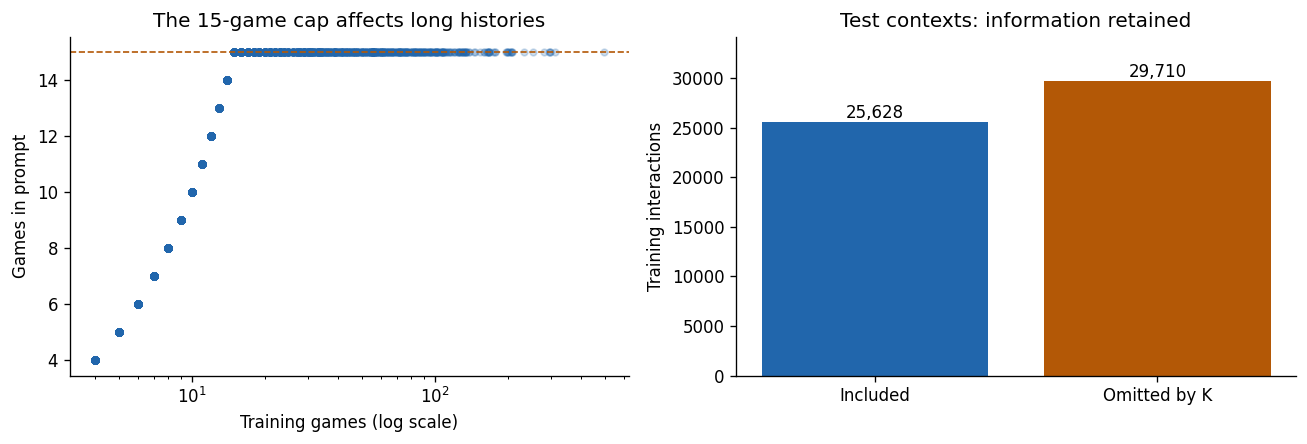

In [5]:
retention = pd.DataFrame([
    {'Context': split, 'Source interactions': sum(r['history_games'] for r in rows),
     'Rendered interactions': sum(r['rendered_games'] for r in rows),
     'Omitted by K': sum(r['omitted_by_k'] for r in rows),
     'Users capped by K': sum(r['omitted_by_k'] > 0 for r in rows),
     'Capped users (%)': 100 * sum(r['omitted_by_k'] > 0 for r in rows) / len(rows)}
    for split, rows in records.items()
])
display(retention.round(2))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
test_frame = pd.DataFrame(records['test'])
axes[0].scatter(test_frame['history_games'], test_frame['rendered_games'], alpha=.22, s=16, color='#2166ac')
axes[0].set(xscale='log', xlabel='Training games (log scale)', ylabel='Games in prompt', title='The 15-game cap affects long histories')
axes[0].axhline(settings['k'], color='#b35806', linestyle='--', linewidth=1)
axes[1].bar(['Included', 'Omitted by K'],
            [test_frame['rendered_games'].sum(), test_frame['omitted_by_k'].sum()], color=['#2166ac', '#b35806'])
axes[1].set(ylabel='Training interactions', title='Test contexts: information retained')
for i, count in enumerate([test_frame['rendered_games'].sum(), test_frame['omitted_by_k'].sum()]):
    axes[1].text(i, count, f'{count:,}', ha='center', va='bottom')
axes[1].set_ylim(0, test_frame['omitted_by_k'].sum() * 1.15)
fig.tight_layout()
plt.show()

## 4. Measure the real token cost

We use the tokenizer files from
[Google's Gemma 4 E2B instruction-tuned model](https://huggingface.co/google/gemma-4-E2B-it/tree/3e22461f65e89153144f8adb70e3b8c2cc9845a7),
pinned to a full commit and SHA-256 checksums. `tokenizers==0.23.2` runs the saved
normalizer, pre-tokenizer, and vocabulary on CPU. No weights are downloaded.

The saved tokenizer's post-processor does not add BOS. Our explicit input contract is
**one BOS token + plain history**, with no EOS, chat turns, generation prefix, padding,
or truncation. That is a modeling choice for the planned hidden-state scoring approach;
the model checkpoint must reuse this contract. A different chat template would require
new measurements. The table reports both text tokens and full input tokens.

In [6]:
input_ids = tokenizer.encode(rendered.text)
raw_ids = tokenizer.backend.encode(rendered.text, add_special_tokens=False).ids
assert input_ids == [tokenizer.bos_id] + raw_ids
print(TOKEN_CONTRACT)
print('Text tokens:', len(raw_ids), '| Input tokens:', len(input_ids), '| BOS ID:', tokenizer.bos_id)
display(pd.DataFrame({'First input IDs': input_ids[:12],
                      'Tokenizer pieces': [tokenizer.backend.id_to_token(i) for i in input_ids[:12]]}))
length_table = pd.DataFrame([
    {'Context': split, 'Count type': field, **stats['splits'][split][field]}
    for split in ('validation', 'test') for field in ('text_tokens', 'input_tokens')
]).drop(columns='std')
display(length_table.round(2))

one BOS + plain history; no EOS, chat template, padding, or token truncation
Text tokens: 168 | Input tokens: 169 | BOS ID: 2


,First input IDs,Tokenizer pieces
0,2,<bos>
1,2094,This
2,4155,▁player
3,236789,'
4,236751,s
5,1346,▁most
6,236772,-
7,61101,played
8,4972,▁games
9,236787,:


,Context,Count type,count,max,mean,median,min,p25,p75,p90,p99
0,validation,text_tokens,2436,235,110.37,115.0,31,61.0,157.0,168.0,187.65
1,validation,input_tokens,2436,236,111.37,116.0,32,62.0,158.0,169.0,188.65
2,test,text_tokens,2436,235,116.64,125.5,39,71.0,158.0,168.0,188.00
3,test,input_tokens,2436,236,117.64,126.5,40,72.0,159.0,169.0,189.00


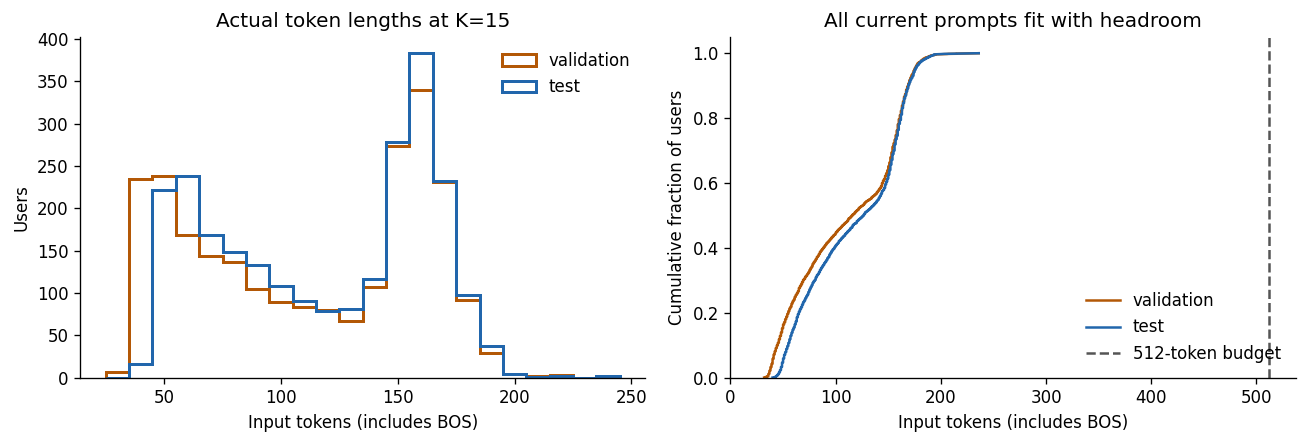

,Context,Over budget,Max input tokens
0,test,0,236
1,validation,0,236


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
bins = np.arange(25, 251, 10)
for split, color in [('validation', '#b35806'), ('test', '#2166ac')]:
    lengths = np.array([r['input_tokens'] for r in records[split]])
    axes[0].hist(lengths, bins=bins, histtype='step', linewidth=1.8, color=color, label=split)
    axes[1].plot(np.sort(lengths), np.arange(1, len(lengths) + 1) / len(lengths), color=color, label=split)
axes[0].set(xlabel='Input tokens (includes BOS)', ylabel='Users', title='Actual token lengths at K=15')
axes[0].legend(frameon=False)
axes[1].axvline(settings['max_tokens'], color='#555555', linestyle='--', label='512-token budget')
axes[1].set(xlabel='Input tokens (includes BOS)', ylabel='Cumulative fraction of users',
            xlim=(0, settings['max_tokens'] * 1.05), ylim=(0, 1.05), title='All current prompts fit with headroom')
axes[1].legend(frameon=False, loc='lower right')
fig.tight_layout()
plt.show()
display(pd.DataFrame([{'Context': split, 'Over budget': values['over_budget'],
                       'Max input tokens': values['input_tokens']['max']}
                      for split, values in stats['splits'].items()]))

The largest input is **236 tokens**, below the 512-token starting budget, and no prompt
was token-truncated. The game-count cap still removes many interactions: token headroom
does not establish that K=15 is the best recommendation setting. A future K ablation
should use validation recommendation metrics, then evaluate test only after selection.

## 5. Reproduce every prompt and check both holdouts

Rebuild all 4,872 contexts with the implementation and actual tokenizer. Check selected
IDs against the appropriate fitting rows, both holdout sets, K, saved token counts, and
saved distributions. Test users whose targets have no training support still receive
contexts; the evaluator's existing zero-credit coverage policy remains in force.

In [8]:
for split in ('validation', 'test'):
    rebuilt = build_records(sources, tokenizer, split=split, k=settings['k'],
                            strategy=settings['strategy'], max_tokens=settings['max_tokens'])
    assert rebuilt == records[split]
    assert summarize_records(rebuilt) == stats['splits'][split]
    allowed = {(row.user_id, sources['mapping'][row.game_title])
               for row in sources['fit' if split == 'validation' else 'train']}
    for row in rebuilt:
        assert not set(row['game_ids']) & set(row['excluded_game_ids'])
        assert all((row['user_id'], game) in allowed for game in row['game_ids'])
        assert 1 <= len(row['game_ids']) <= settings['k']
        assert row['input_tokens'] == row['text_tokens'] + 1
        assert row['excluded_from_source'] == 0
    print(f'{split}: all {len(rebuilt):,} prompts and token counts reproduced; no held-out IDs included.')

validation: all 2,436 prompts and token counts reproduced; no held-out IDs included.


test: all 2,436 prompts and token counts reproduced; no held-out IDs included.


## 6. Ten prompts for your review

Users are sorted by training-history size, with SHA-256(seed:user ID) tie ordering.
We take ten evenly spaced positions, including the shortest and longest histories.
This is a deterministic inspection sample, not a statistically representative sample
and not a selection of successful recommendations. Targets shown below are audit
labels outside the text supplied to the tokenizer.

When reviewing, consider readability, whether hours communicate useful preference,
and how much the longest histories lose at K=15. The same ten full prompts are in
[`results/verbalization/samples.md`](../results/verbalization/samples.md).

In [9]:
samples = select_samples(records['test'], settings['review_samples'], config['data'].seed)
assert [row['user_id'] for row in samples] == stats['sample_user_ids']
display(pd.DataFrame([{key: row[key] for key in
                       ('user_id', 'history_games', 'rendered_games', 'omitted_by_k', 'input_tokens')}
                      for row in samples]))

,user_id,history_games,rendered_games,omitted_by_k,input_tokens
0,53258793,4,4,0,51
1,92904111,4,4,0,51
2,153821154,6,6,0,78
3,67965357,7,7,0,76
4,59756932,10,10,0,109
5,242523654,13,13,0,150
6,26027937,18,15,3,160
7,61632730,28,15,13,166
8,182399789,51,15,36,172
9,62990992,497,15,482,177


In [10]:
for index, row in enumerate(samples, 1):
    target_title = sources['display'][row['target_game_id']]
    display(HTML(f'<h3>{index}. User {row["user_id"]}</h3>'
                 f'<p>{row["history_games"]} training games; {row["rendered_games"]} rendered; '
                 f'{row["omitted_by_k"]} omitted by K; {row["input_tokens"]} input tokens.</p>'
                 '<pre style="white-space:pre-wrap;line-height:1.6;padding:16px;border:1px solid #ccc">'
                 + escape(row['prompt']) + '</pre>'
                 + f'<p><em>Audit-only test label, excluded:</em> {escape(target_title)} (ID {row["target_game_id"]})</p>'))

## Checkpoint boundary

This checkpoint prepares reproducible evaluation text and its token-cost audit. It
does not define an LLM ranker, add training targets, or claim new recommendation scores.
After prompt review, the next checkpoint is a model forward pass and shape/VRAM checks.

Existing limitations still apply: random rather than temporal holdouts, engagement
hours as a noisy proxy, a historical small catalog, cold-start targets, and offline-only
evaluation. Top-K additionally omits lower-hour interests, while game names may be
ambiguous without metadata. All decisions and artifacts can be traced back to the
unchanged processed split and baseline validation membership.

In [11]:
assert before == {path: file_hash(path) for path in protected}
verify_artifacts(config['artifacts_dir'], make_identity(config, sources))
print(f'All {len(protected)} prior data/baseline/result files remain byte-identical.')
print('Verbalizer artifacts verified. Ready for human review of the ten sample prompts.')

All 20 prior data/baseline/result files remain byte-identical.
Verbalizer artifacts verified. Ready for human review of the ten sample prompts.
